<a href="https://colab.research.google.com/github/cynthiiaa/neuralgcm-workshop/blob/main/AMLC_Main_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeuralGCM Workshop

This workshop is for data scientists and ML engineers who are comfortable with:
- Python, NumPy, Pandas
- basic ML ideas (loss functions, gradients, train and eval loops)
- reading and editing code in notebooks

You do not need to be a climate scientist! The goal is to learn how data practitioners in different industries/fields tackle interesting problems and see where we can apply that to our own work.

We will use a 1D system (advection + diffusion) that behaves like a simplified version of what NeuralGCM does.

## By the End of This Workshop You Will Have
- Built a **hybrid model**: macro-level rules based equations + a neural net that learns the micro-level, complex patterns.
- Trained the neural net **in context** (online training)
- ~Debug and test the coupled system~
- See if this architecture can be applied in your own work

### NeuralGCM splits its open-source implementation across two repos:
- **dinosaur**: the differentiable dynamical core (the physics engine)
- **neuralgcm**: ML components and trained checkpoints

In this workshop:
- `SimpleDynamics` plays the role of a dynamical core
- `LearnedPhysics` plays the role of the neural network
- `HybridModel` is the pairing between the first two models

<br>
🔔 Checkout the JAX primer if you haven't used JAX before.


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import time
from flax import linen as nn

print(f"JAX version: {jax.__version__}")
print(f"Backend: {jax.default_backend()}")
print(f"Devices: {jax.devices()}")

JAX version: 0.7.2
Backend: gpu
Devices: [CudaDevice(id=0)]


# Part 1

In modeling complex systems, **we often rely on a trusted foundational structure** (for example: established physical laws, strict constraints, and deep domain expertise). However, these theoretical rules rarely capture the full, messy reality of the system. The gap between what our equations predict and what actually occurs in the real world is where machine learning comes in handy.

- trusted equations capture large-scale dynamics
- a neural net learns hard-to-model residual effects
- training is done end-to-end so the two components work together

### NeuralGCM applies this in weather:
**The Physics Engine (Trusted Structure):** The foundation of the model is a "dynamical core" that acts as a traditional physics simulator. It calculates large-scale atmospheric movements governed by well-understood forces like gravity and the Earth's rotation. It relies on established mathematical equations (the rules).

**The Machine Learning Module (Learning the Details):** Traditional physics equations are great at the *big picture* but struggle to simulate highly complex, small-scale events. To fill this gap, NeuralGCM uses a neural network to predict localized phenomena. This AI component handles the messy, hard-to-model details like cloud formation, rainfall, and how heat radiates.

**Integrated, End-to-End Training:** NeuralGCM uses JAX which allows the neural network to be trained "online". Meaning it learns and adjusts while actively interacting with the physics engine over hundreds of simulated time steps.


### The same pattern shows up in analytics & ML

| Domain | Known structure | What ML learns |
|--------|------------------|----------------|
| Fraud / compliance| accounting identities, policy rules, known constraints | behavioral residuals, subtle interactions |
| Forecasting | trend, seasonality, calendar effects, autoregressive structure | shocks, regime shifts, residual errors |
| Risk scoring | baseline formulas + eligibility rules | residual risk, nonlinear effects |
| Operations / queueing / supply chains | conservation laws, queueing dynamics, routing logic| state-dependent delays, behavior-driven variability, correction terms |
| Traffic / transportation | how traffic density and queues evolve over time | driver behavior, merging effects, sudden slowdowns|

## Why JAX for this pattern?

To successfully train a combined system like NeuralGCM, it must calculate exactly how its final forecast error changes in response to tiny adjustments across millions of variables. The machine learning component of NeuralGCM (which predicts complex, small-scale weather details) relies on between **11.5 million and 31.1 million parameters**! To improve the model's accuracy, the training process has to figure out precisely how to tweak every single one of these millions of parameters to shrink the final prediction error.

## The Ingenuity 🧠
Calculating these precise adjustments would normally be mathematically impossible 💀 But since NeuralGCM evaluates its performance by letting the AI and the physics engine talk to each other ("online" training), it's possible and genius!!! The researchers built the core physics engine using JAX, a framework that provides automatic differentiation 😏.

JAX calculates the necessary adjustments by tracing the cause-and-effect of a forecasting mistake backward through time, step-by-step, to pinpoint exactly which neural network parameters contributed to the error. The system then uses an optimization algorithm (***stochastic gradient descent***) to update those millions of parameters simultaneously. This process is what allows the AI to "*see*" how its localized, short-term predictions will affect the physics engine.

The researchers achieve this by gradually expanding the model's training window, starting with 6-hour forecasts and extending all the way to 5 days.


### JAX gives you:
- **NumPy-style arrays** (`jax.numpy`) so the code feels familiar
- **automatic differentiation** (`jax.grad`) to get gradients automagically
- **JIT compilation** (`jax.jit`) for fast,performant code

# Quick refresher: SGD and Backpropagation

## Stochastic Gradient Descent (SGD)

We want to pick parameters `theta` that make a loss small:

- `loss(theta)` measures how wrong the model is
- the gradient `grad(loss)` tells us the local rate of change of the loss with respect to each parameter

SGD update rule (one step):

$$\theta \leftarrow \theta - \eta \,\nabla_{\theta} \mathcal{L}(\theta)$$

To improve the model, we slightly adjust θ to make the loss smaller. The gradient tells us which way the loss goes up, and we step the other way. The learning rate decides how big that adjustment is (it's a fator).

Essentially means we move θ by a small amount in the direction that reduces the loss.

* The gradient tells you the direction (and how steep) to change θ to reduce the loss.
* The learning rate η tells you how big a step to take in that direction.

<br>

Why "stochastic"? Because we estimate the gradient using a **mini-batch** (a small sample) instead of the full dataset.
This makes training fast and usually works well in practice.

If you have used sklearn models: the library is doing some version of this internally for many estimators.




## Backpropagation

Backprop is just the **chain rule** applied many times.

The loss depends on the model output, the output depends on intermediate computations, and those intermediates depend on the parameters. So we use chain rule to compute how changing each parameter would change the loss.

$$\frac{\partial \mathcal{L}}{\partial \theta}
=
\frac{\partial \mathcal{L}}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial h}
\cdot
\frac{\partial h}{\partial \theta}$$

Each term tells us how a change in one quantity affects the next, and multiplying them chains those effects together back to the parameters.

<br>

Backprop efficiently computes how each parameter affects the loss by reusing intermediate results.

$$\nabla_{\theta}\mathcal{L}(\theta)
=
\begin{bmatrix}
\frac{\partial \mathcal{L}}{\partial \theta_1}\\
\frac{\partial \mathcal{L}}{\partial \theta_2}\\
\vdots\\
\frac{\partial \mathcal{L}}{\partial \theta_n}
\end{bmatrix}$$

## Why this matters
Offline training focuses on one-step predictions. Using past examples, the ML model learns how the state should change over one step.

Online training makes the loss depend on many repeated updates:

$$\theta \;\rightarrow\; \text{update} \;\rightarrow\; \text{state}_1 \;\rightarrow\; \text{update} \;\rightarrow\; \text{state}_2 \;\rightarrow\; \cdots \;\rightarrow\; \mathcal{L}_{\text{trajectory}}
$$

> θ controls the update rule; repeated updates create a sequence of states; and the trajectory loss depends on that whole sequence, so it’s influenced by all earlier states.

Gradients have to flow through **the whole rollout** (simulating many time steps forward).

This is where JAX shines: it can differentiate through code that includes both:
- "physics" operations
- neural network operations

<br>

⭐️ "end-to-end" means gradients flow through the simulation + the neural net together

In [2]:
# Demo 1: Gradients through physics

def simple_dynamics(state, velocity):
    """Simple advection: d/dt = -velocity * d/dx
    Uses periodic BCs via jnp.roll (central differences).
    """
    dx = 1.0 / len(state)
    dstate_dx = (jnp.roll(state, -1) - jnp.roll(state, 1)) / (2 * dx)
    return -velocity * dstate_dx

# Create test state
x = jnp.linspace(0, 1, 100)
state = jnp.sin(2 * jnp.pi * x)  # Sine wave
velocity = 1.0

# Compute advection
advection = simple_dynamics(state, velocity)

# Get gradient with respect to velocity
grad_fn = jax.grad(lambda v: jnp.sum(simple_dynamics(state, v)**2))
gradient = grad_fn(velocity)

print(f"Gradient of loss w.r.t. velocity: {gradient}")
print("\n💡 We can backprop through physics equations!")

Gradient of loss w.r.t. velocity: 3942.14208984375

💡 We can backprop through physics equations!


In [3]:
# Demo 2: JIT compilation for speed

def slow_function(x):
    for i in range(100):
        x = jnp.sin(x) + jnp.cos(x)
    return x

fast_function = jax.jit(slow_function)

# Time both
x = jnp.ones(1000)

# Warm up JIT (first call triggers compilation)
fast_function(x).block_until_ready()

# block_until_ready() ensures JAX async dispatch is complete before timing
start = time.time()
result_slow = slow_function(x).block_until_ready()
time_slow = time.time() - start

start = time.time()
result_fast = fast_function(x).block_until_ready()
time_fast = time.time() - start

print(f"Slow version: {time_slow:.6f}s")
print(f"JIT version:  {time_fast:.6f}s")
print(f"Speedup: {time_slow/time_fast:.1f}x")

Slow version: 0.152677s
JIT version:  0.000357s
Speedup: 428.1x


## What NeuralGCM does (and why it matters beyond climate)

Traditional GCMs filled in the complex, micro-physics with hand-coded (hand-written) parameterizations.

Parameterizations are expert-built approximations that can be hard to tune, brittle, and slow to evolve.

NeuralGCM replaces that manual part with a neural network, but the main distinction is how that trained model works with a dynamical core.

### Offline training
Train the neural net to predict the missing term from one-step snapshots, then plug it into the simulator.

This often fails because the net never learns how its errors accumulate over time.

### Online training (NeuralGCM approach)
Train the neural net while it is connected to the simulator.
The loss is computed over a rollout, so gradients flow through every time step.

Instead of training on just the next step, NeuralGCM runs the model forward for several steps in a row, then measures how well the whole sequence matches reality. During training, it sends the learning signal back through all of those steps, so the neural network learns how its corrections interact with the physics core. They also start with short rollouts and gradually train on longer ones.

### In this workshop you will implement both approaches, then compare them.


In [4]:
def generate_synthetic_data(n_steps=100):
    """Generate truth data with known physics + diffusion"""
    x = jnp.linspace(0, 1, 100)
    dx = 1.0 / 100
    dt = 0.001
    velocity = 0.5
    diffusion = 0.01

    # Initial condition: Gaussian curve
    initial_state = jnp.exp(-((x - 0.5)**2) / 0.01)

    def step_fn(state, _):
        # Advection (known physics)
        advection = -velocity * (jnp.roll(state, -1) - jnp.roll(state, 1)) / (2 * dx)

        # Diffusion (what the neural net should learn)
        laplacian = (jnp.roll(state, 1) - 2*state + jnp.roll(state, -1)) / (dx**2)
        diffusion_term = diffusion * laplacian

        new_state = state + dt * (advection + diffusion_term)
        return new_state, new_state

    # Use lax.scan instead of Python loop it's JIT-compilable and faster
    _, states = jax.lax.scan(step_fn, initial_state, None, length=n_steps)

    # Prepend initial state
    return jnp.concatenate([initial_state[None], states])

truth_data = generate_synthetic_data(100)

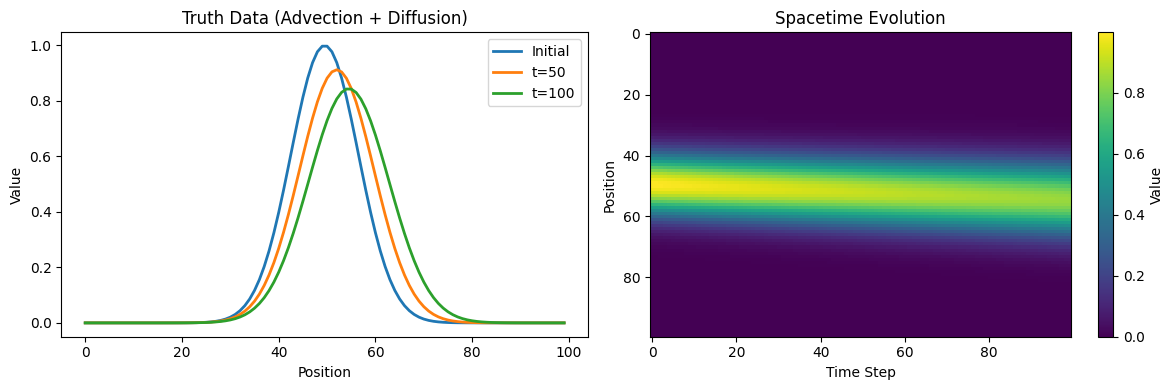

Shape: (101, 100) (time_steps, spatial_points)


In [5]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(truth_data[0], label='Initial', linewidth=2)
plt.plot(truth_data[50], label='t=50', linewidth=2)
plt.plot(truth_data[-1], label='t=100', linewidth=2)
plt.legend()
plt.title('Truth Data (Advection + Diffusion)')
plt.xlabel('Position')
plt.ylabel('Value')

plt.subplot(1, 2, 2)
plt.imshow(truth_data[:100].T, aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title('Spacetime Evolution')
plt.xlabel('Time Step')
plt.ylabel('Position')
plt.tight_layout()
plt.show()

print(f"Shape: {truth_data.shape} (time_steps, spatial_points)")

---

# Part 3: Exercise 1 - Build a Hybrid Model (20 min)

We'll work with a 1D system that has two parts:

- **Advection** (known): transport by flow.
  We'll code this explicitly.

  $$\frac{\partial u}{\partial t} + v\,\frac{\partial u}{\partial x} = 0$$

- **Diffusion** (unknown): spreading / smoothing.
  We'll pretend we do not know the diffusion equation and ask the neural net to learn it from data.


| NeuralGCM component | Our 1D version |
|---------------------|----------------|
| dynamical core | `SimpleDynamics` (advection) |
| learned physics | `LearnedPhysics` (MLP) |
| solver | `HybridModel` (forward Euler) |
| training data | synthetic trajectories |

### Your task
Implement:
1. `SimpleDynamics.tendency(state)` - the known rule
2. `LearnedPhysics.__call__(state)` - a small MLP that outputs a tendency
3. `HybridModel.step(...)` and `HybridModel.rollout(...)` - connect the pieces and run a rollout

Tip: keep everything shape-consistent (1D arrays of length `grid_size`).


In [6]:
# Exercise 1.1: Implement SimpleDynamics class

class SimpleDynamics:
    """Handles known physics: advection equation

    Note: Registered as a JAX pytree so it works with jit/grad.
    Plain Python classes with mutable state can cause tracing issues.
    """

    def __init__(self, grid_size=100, velocity=0.5):
        self.grid_size = grid_size
        self.dx = 1.0 / grid_size
        self.velocity = velocity

    def tendency(self, state):
        """
        Compute advection tendency: -velocity * d(state)/dx
        Uses periodic boundary conditions (jnp.roll) to be consistent
        with the diffusion operator.

        TODO: Implement this function
        Hint: Use central differences with jnp.roll for periodic BCs:
              d/dx ≈ (roll(state,-1) - roll(state,1)) / (2*dx)

        Args:
            state: 1D array of values
        Returns:
            tendency: Rate of change due to advection
        """
        # YOUR CODE HERE
        spatial_derivative = (jnp.roll(state, -1) - jnp.roll(state, 1)) / (2 * self.dx)
        return -self.velocity * spatial_derivative

# Register as a JAX pytree (needed for jit/grad compatibility)
jax.tree_util.register_pytree_node(
    SimpleDynamics,
    lambda obj: ((), (obj.grid_size, obj.velocity)),   # flatten
    lambda aux, _: SimpleDynamics(aux[0], aux[1]),      # unflatten
)

# Test your implementation
dynamics = SimpleDynamics()
test_state = jnp.sin(2 * jnp.pi * jnp.linspace(0, 1, 100))
tendency = dynamics.tendency(test_state)
print(f"Advection tendency shape: {tendency.shape}")
print(f"Advection tendency mean: {jnp.mean(jnp.abs(tendency)):.6f}")

Advection tendency shape: (100,)
Advection tendency mean: 1.998741


In [7]:
# Exercise 1.2: Implement LearnedPhysics neural network

class LearnedPhysics(nn.Module):
    """Neural network to learn unresolved physics (diffusion)"""

    hidden_features: tuple[int, ...] = (32, 32)
    output_dim: int = 1

    @nn.compact
    def __call__(self, state):
        """
        Predict physics tendency from state

        TODO: Implement a simple MLP
        Architecture:
        - Input: state (needs reshaping to add feature dimension)
        - Hidden layers: 32 → 32 with ReLU
        - Output: 1 (tendency at each point)

        Args:
            state: 1D array [grid_size]
        Returns:
            tendency: Predicted tendency [grid_size]
        """
        # YOUR CODE HERE
        # Hint 1: Reshape state to [grid_size, 1]
        # Hint 2: Use nn.Dense for layers
        # Hint 3: Use nn.relu for activation
        # Hint 4: Final output should be [grid_size, 1], squeeze to [grid_size]
        x = state.reshape(-1, 1)

        # Hidden layers
        for feat in self.hidden_features:
            x = nn.Dense(feat)(x)
            x = nn.relu(x)

        # Output layer
        x = nn.Dense(self.output_dim)(x)

        # Squeeze back to 1D
        return x.squeeze()

# Test initialization
key = jax.random.PRNGKey(0)
learned = LearnedPhysics()
params = learned.init(key, test_state)
print("✅ LearnedPhysics initialized")

✅ LearnedPhysics initialized


In [8]:
# Exercise 1.3: Combine into HybridModel

class HybridModel:
    """Combines dynamics + learned physics

    Registered as a JAX pytree for jit/grad compatibility.
    """

    def __init__(self, grid_size=100):
        self.dynamics = SimpleDynamics(grid_size=grid_size)
        self.learned_physics = LearnedPhysics()
        self.dt = 0.001  # Time step
        # NOTE: Forward Euler is first-order and has strict stability limits
        # (dt < dx^2 / 2D for diffusion). NeuralGCM uses higher-order solvers.
        # If you change dt or diffusivity and see instability, this is why.

    def step(self, state, params):
        """
        Advance state by one time step

        TODO: Implement forward Euler integration
        new_state = state + dt * (dynamics_tendency + learned_tendency)

        Args:
            state: Current state
            params: Neural network parameters
        Returns:
            new_state: State after one time step
        """
        # YOUR CODE HERE
        dynamics_tendency = self.dynamics.tendency(state)
        learned_tendency = self.learned_physics.apply(params, state)

        total_tendency = dynamics_tendency + learned_tendency
        new_state = state + self.dt * total_tendency

        return new_state

    def rollout(self, initial_state, params, n_steps):
        """
        Simulate for multiple steps

        TODO: Use jax.lax.scan for a JIT-compilable rollout
        (Avoid Python for-loops with list appends — they prevent JIT compilation)

        Hint:
            def scan_fn(state, _):
                new_state = self.step(state, params)
                return new_state, new_state
            _, states = jax.lax.scan(scan_fn, initial_state, None, length=n_steps)

        Args:
            initial_state: Starting state
            params: Neural network parameters
            n_steps: Number of steps to simulate
        Returns:
            states: Array of states [n_steps+1, grid_size]
        """
        # YOUR CODE HERE
        def scan_fn(state, _):
            new_state = self.step(state, params)
            return new_state, new_state

        _, states = jax.lax.scan(scan_fn, initial_state, None, length=n_steps)

        # Prepend initial state for shape [n_steps+1, grid_size]
        return jnp.concatenate([initial_state[None], states])

# Register as a JAX pytree
jax.tree_util.register_pytree_node(
    HybridModel,
    lambda obj: ((), (obj.dynamics, obj.learned_physics, obj.dt)),
    lambda aux, _: _make_hybrid_model(*aux),
)

def _make_hybrid_model(dynamics, learned_physics, dt):
    m = object.__new__(HybridModel)
    m.dynamics = dynamics
    m.learned_physics = learned_physics
    m.dt = dt
    return m

# Test
model = HybridModel()
test_rollout = model.rollout(test_state, params, n_steps=10)
print(f"Rollout shape: {test_rollout.shape}")
print("✅ HybridModel working")

Rollout shape: (11, 100)
✅ HybridModel working


# Part 4: Exercise 2 - Training (25 min)

## Step-by-Step vs Rollout

In online training, we don’t score the model after just one step. We let it run for a while and score the entire trajectory it produces.

The rollout length is simply how many updates we apply before we compute the loss.

- Short rollouts are faster and easier to train, but they don’t strongly reward long-term stability.
- Long rollouts teach the model to behave well over time, but they cost more and can be harder to optimize at the start.

NeuralGCM starts with short rollouts and gradually increases the length. In this workshop we’ll keep it simple and use a fixed rollout length of 30 steps.

In [9]:
def generate_synthetic_data(n_steps=200, grid_size=100):
  """Generate 'truth' data with known physics + diffusion"""
  x = jnp.linspace(0, 1, grid_size)
  dx = 1.0 / grid_size
  dt = 0.001
  velocity = 0.5
  diffusion = 0.01

  # Initial condition: Gaussian bump
  initial_state = jnp.exp(-((x - 0.5)**2) / 0.01)

  def step_fn(state, _):
      # Advection — periodic BCs via jnp.roll (consistent with diffusion)
      advection = -velocity * (jnp.roll(state, -1) - jnp.roll(state, 1)) / (2 * dx)

      # Diffusion
      laplacian = (jnp.roll(state, 1) - 2*state + jnp.roll(state, -1)) / (dx**2)
      diffusion_term = diffusion * laplacian

      new_state = state + dt * (advection + diffusion_term)
      return new_state, new_state

  # Use lax.scan instead of Python loop — JIT-compilable and faster
  _, states = jax.lax.scan(step_fn, initial_state, None, length=n_steps)

  # Prepend initial state
  return jnp.concatenate([initial_state[None], states])

# Generate data
truth_data = generate_synthetic_data(1000)
print(f"✅ Truth data shape: {truth_data.shape}")

✅ Truth data shape: (1001, 100)


## Offline training (baseline)
We'll implement offline training first.
It is useful, and often works for one-step predictions, but it can produce a model that drifts or becomes unstable when predicting over longer periods of time.

### Exercise 2.1: Implement offline training

In [10]:
def offline_training(truth_data, n_epochs=100, key=None):
    """
    Train ML to predict diffusion from snapshots ("historical" data)

    TODO: Implement offline training loop
    For each snapshot:
    1. Compute true diffusion: (next_state - current_state - advection_tendency * dt) / dt
    2. Predict diffusion with NN
    3. MSE loss between prediction and true diffusion

    Args:
        truth_data: Ground truth trajectories
        n_epochs: Number of training epochs
        key: JAX PRNG key (pass in and split for reproducibility)
    Returns:
        trained_params: Optimized NN parameters
    """
    if key is None:
        key = jax.random.PRNGKey(42)
    key, init_key = jax.random.split(key)

    # Initialize model
    model = HybridModel()
    params = model.learned_physics.init(init_key, truth_data[0])

    # Optimizer
    optimizer = optax.adam(1e-3)
    opt_state = optimizer.init(params)

    # YOUR CODE HERE
    # Hint: Compute target diffusion from consecutive states
    # Hint: Use jax.value_and_grad for loss computation

    @jax.jit
    def loss_fn(params, state, next_state):
      # Compute what diffusion should be
      dt = model.dt
      dynamics_tendency = model.dynamics.tendency(state)

      # True change minus advection = diffusion
      true_diffusion = (next_state - state) / dt - dynamics_tendency

      # Predict diffusion
      pred_diffusion = model.learned_physics.apply(params, state)

      # MSE loss
      return jnp.mean((pred_diffusion - true_diffusion)**2)

    @jax.jit
    def train_step(params, opt_state, state, next_state):
      loss, grads = jax.value_and_grad(loss_fn)(params, state, next_state)
      updates, opt_state = optimizer.update(grads, opt_state, params)
      params = optax.apply_updates(params, updates)
      return params, opt_state, loss

    # Training loop
    losses = []
    for epoch in range(n_epochs):
      epoch_loss = 0
      for i in range(0, len(truth_data)-1, 10):  # Sample every 10th
          params, opt_state, loss = train_step(
              params, opt_state, truth_data[i], truth_data[i+1]
          )
          epoch_loss += loss

      losses.append(epoch_loss)
      if epoch % 10 == 0:
          print(f"Epoch {epoch}, Loss: {epoch_loss:.6f}")

    return params, losses

# Train
offline_params, _ = offline_training(truth_data, n_epochs=100)
print("✅ Offline training complete")

Epoch 0, Loss: 2.941655
Epoch 10, Loss: 0.976881
Epoch 20, Loss: 0.976205
Epoch 30, Loss: 1.034819
Epoch 40, Loss: 1.067334
Epoch 50, Loss: 1.075542
Epoch 60, Loss: 1.077284
Epoch 70, Loss: 1.076174
Epoch 80, Loss: 1.075568
Epoch 90, Loss: 1.072624
✅ Offline training complete


## Online training (NeuralGCM approach)

Now train the same learned component, but with the loss computed over a rollout of the coupled system.

We're computing forward 30 time steps and then comparing the entire 30-step trajectory to what actually happened in the truth data.

## 💡
- `loss_fn` runs `model.rollout(...)`
- `model.rollout(...)` chains together 30 predictions
- the loss compares the entire predicted trajectory to truth
- gradients flow backward through time, so the neural network learns how its predictions compound over time

This is the setting where JAX really matters: you get end-to-end gradients


### Exercise 2.2: Implement online training

In [11]:
def online_training(truth_data, rollout_length=30, n_epochs=100, key=None):
    """
    Train ML with rollouts (context of dynamics)

    TODO: Implement online training
    For each initial condition:
    1. Rollout hybrid model for `rollout_length` steps
    2. Compare rollout to truth trajectory
    3. Backprop through ENTIRE rollout

    Args:
        truth_data: Ground truth trajectories
        rollout_length: How many steps to rollout
        n_epochs: Training epochs
        key: JAX PRNG key (pass in and split for reproducibility)
    Returns:
        trained_params: Optimized NN parameters
    """
    if key is None:
        key = jax.random.PRNGKey(42)
    key, init_key = jax.random.split(key)

    model = HybridModel()
    params = model.learned_physics.init(init_key, truth_data[0])

    optimizer = optax.adam(1e-3)
    opt_state = optimizer.init(params)

    # YOUR CODE HERE
    # Key difference from offline:
    # - Use model.rollout() in the loss function
    # - Gradients flow through the entire trajectory

    @jax.jit
    def loss_fn(params, initial_state, truth_trajectory):
      # Rollout hybrid model
      pred_trajectory = model.rollout(initial_state, params, rollout_length)

      # Compare to truth
      # Note: pred_trajectory includes initial state, so shapes match
      return jnp.mean((pred_trajectory - truth_trajectory)**2)

    @jax.jit
    def train_step(params, opt_state, initial_state, truth_trajectory):
      loss, grads = jax.value_and_grad(loss_fn)(
          params, initial_state, truth_trajectory
      )
      updates, opt_state = optimizer.update(grads, opt_state, params)
      params = optax.apply_updates(params, updates)
      return params, opt_state, loss

    # Training loop
    losses = []
    max_start = len(truth_data) - rollout_length - 1
    for epoch in range(n_epochs):
      epoch_loss = 0
      # Sample random starting points (reproducible via JAX PRNG)
      key, sample_key = jax.random.split(key)
      start_indices = jax.random.randint(sample_key, (10,), 0, max_start)
      start_indices = jax.device_get(start_indices)  # avoid per-element device→host transfers
      for idx in range(10):
          start_idx = int(start_indices[idx])
          initial = truth_data[start_idx]
          truth_traj = truth_data[start_idx:start_idx + rollout_length + 1]

          params, opt_state, loss = train_step(
              params, opt_state, initial, truth_traj
          )
          epoch_loss += loss

      losses.append(epoch_loss)
      if epoch % 10 == 0:
          print(f"Epoch {epoch}, Loss: {epoch_loss:.6f}")

    return params, losses

# Train
online_params, _ = online_training(truth_data, rollout_length=20, n_epochs=100)
print("✅ Online training complete")

Epoch 0, Loss: 0.000076
Epoch 10, Loss: 0.000005
Epoch 20, Loss: 0.000022
Epoch 30, Loss: 0.000006
Epoch 40, Loss: 0.000039
Epoch 50, Loss: 0.000011
Epoch 60, Loss: 0.000017
Epoch 70, Loss: 0.000006
Epoch 80, Loss: 0.000006
Epoch 90, Loss: 0.000021
✅ Online training complete


### Exercise 2.3: Compare offline vs online

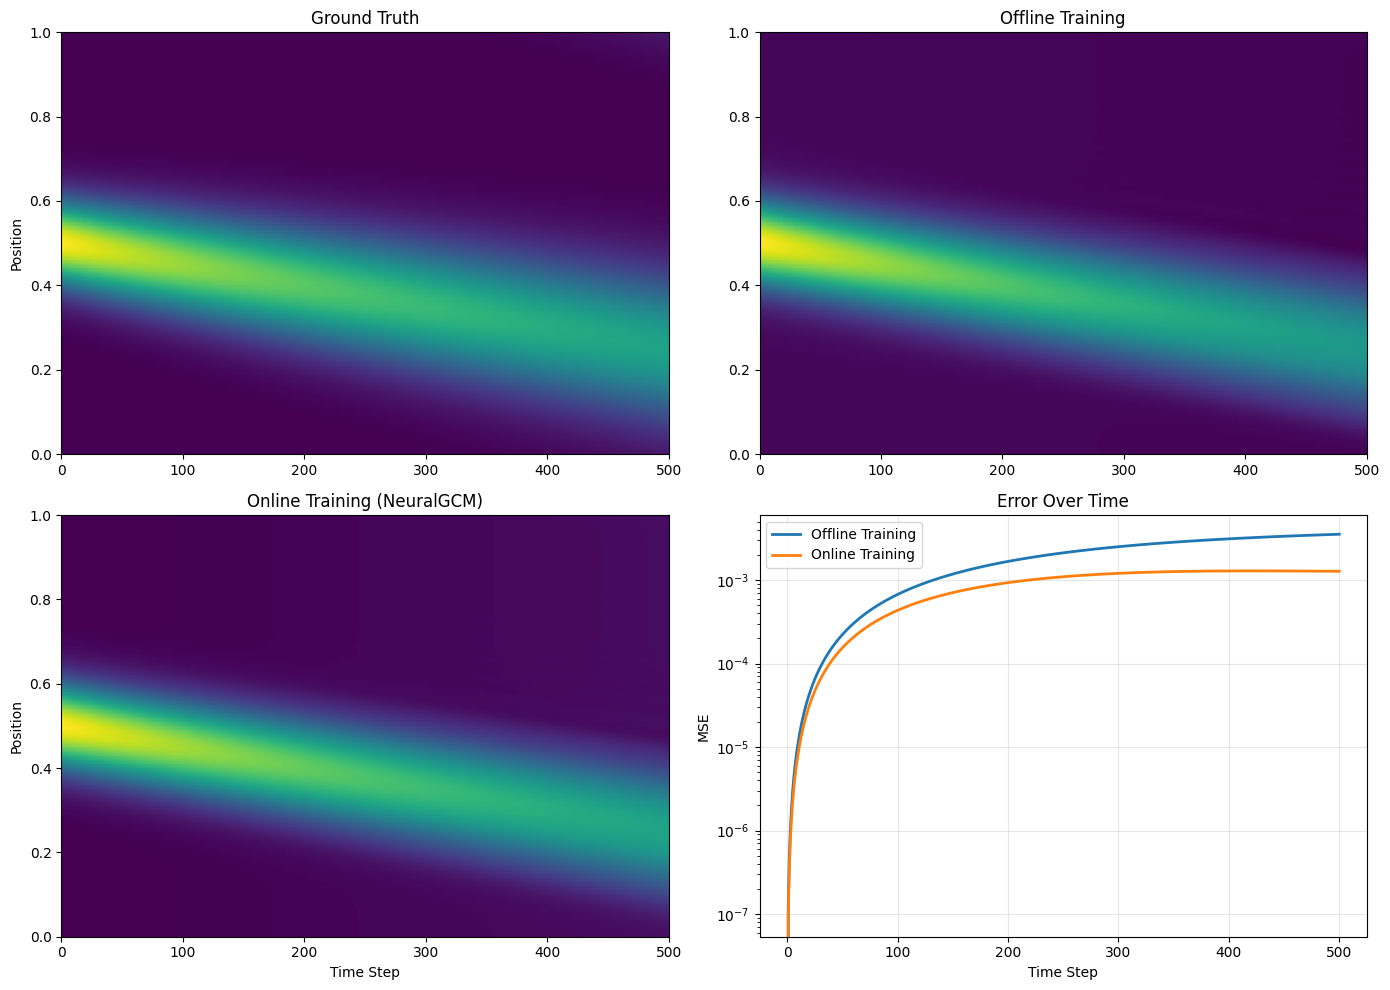


Final MSE (step 500):
  Offline: 0.003536
  Online:  0.001273

✅ Online training is 2.8x better!


In [12]:
def compare_models(truth_data, offline_params, online_params):
    """
    Compare long-term rollouts

    TODO: Generate predictions and plot comparison
    1. Rollout both models for 200 steps
    2. Plot trajectories
    3. Compute MSE over time
    """
    # YOUR CODE HERE
    model = HybridModel()

    # Generate long rollouts
    initial = truth_data[0]
    n_steps = 500

    # Predictions
    offline_pred = model.rollout(initial, offline_params, n_steps)
    online_pred = model.rollout(initial, online_params, n_steps)
    truth = truth_data[:n_steps+1]

    # Compute MSE over time
    offline_mse = jnp.mean((offline_pred - truth)**2, axis=1)
    online_mse = jnp.mean((online_pred - truth)**2, axis=1)

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Trajectories
    ax = axes[0, 0]
    ax.imshow(truth.T, aspect='auto', cmap='viridis', extent=[0, n_steps, 0, 1])
    ax.set_title('Ground Truth')
    ax.set_ylabel('Position')

    ax = axes[0, 1]
    ax.imshow(offline_pred.T, aspect='auto', cmap='viridis', extent=[0, n_steps, 0, 1])
    ax.set_title('Offline Training')

    ax = axes[1, 0]
    ax.imshow(online_pred.T, aspect='auto', cmap='viridis', extent=[0, n_steps, 0, 1])
    ax.set_title('Online Training (NeuralGCM)')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Position')

    # MSE over time
    ax = axes[1, 1]
    ax.plot(offline_mse, label='Offline Training', linewidth=2)
    ax.plot(online_mse, label='Online Training', linewidth=2)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('MSE')
    ax.set_title('Error Over Time')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal MSE (step {n_steps}):")
    print(f"  Offline: {offline_mse[-1]:.6f}")
    print(f"  Online:  {online_mse[-1]:.6f}")
    print(f"\n✅ Online training is {offline_mse[-1]/online_mse[-1]:.1f}x better!")

# Run comparison
compare_models(truth_data, offline_params, online_params)

# Part 5: Exercise 3 - Testing and debugging (15 min)

## Physical constraints are your data integrity checks

When ML is coupled to rules, bugs often show up as drift or instability.

Physics-based systems have invariants (things that should stay consistent over time).
In analytics, you already do the same thing with integrity/sanity checks:
- totals add up correctly
- probabilities are valid
- counts do not go negative
- constraints hold

For our system, we'll use:
- **stability**: no NaNs/Infs, values do not explode
- **mass conservation**: total mass stays about constant

These tests are especially valuable because a coupled system can pass unit tests for each component and still fail when combined.


In [ ]:
# Exercise 3.1: Implement stability test

def test_stability(model, params, initial_state, n_steps=1000):
    """
    Check if model remains stable for long rollouts

    TODO: Implement stability checks
    - Rollout for n_steps
    - Check for NaN or Inf values
    - Check if values explode (> 1e6)

    Args:
        model: HybridModel instance
        params: Model parameters
        initial_state: Starting state
        n_steps: Number of steps to test
    Returns:
        is_stable: Boolean
        max_value: Maximum value encountered
    """
    # YOUR CODE HERE
    trajectory = model.rollout(initial_state, params, n_steps)

    # Check for NaN or Inf
    has_nan = jnp.any(jnp.isnan(trajectory))
    has_inf = jnp.any(jnp.isinf(trajectory))

    # Check for explosions
    max_value = jnp.max(jnp.abs(trajectory))
    exploded = max_value > 1e6

    is_stable = not (has_nan or has_inf or exploded)

    return is_stable, float(max_value)

# Test
is_stable, max_val = test_stability(model, online_params, truth_data[0])
print(f"Stable: {is_stable}, Max value: {max_val:.6f}")

In [ ]:
# Exercise 3.2: Implement conservation test

def test_mass_conservation(trajectory, tolerance=1e-6):
    """
    Check if total mass is conserved

    TODO: Verify conservation
    For advection-diffusion:
    - Total integral should be constant (no sources/sinks)
    - Compute: sum(state) at each time step
    - Check deviation from initial sum

    Args:
        trajectory: States over time [n_steps, grid_size]
        tolerance: Allowed deviation
    Returns:
        passes: Boolean
        deviation: Maximum deviation from initial mass
    """
    # YOUR CODE HERE
    total_mass = jnp.sum(trajectory, axis=1)  # Sum over space at each time

    initial_mass = total_mass[0]
    mass_deviation = jnp.abs(total_mass - initial_mass)
    max_deviation = jnp.max(mass_deviation)

    passes = max_deviation < tolerance

    return passes, float(max_deviation)

# Test
test_traj = model.rollout(truth_data[0], online_params, n_steps=100)
passes, deviation = test_mass_conservation(test_traj)
print(f"Conservation test: {'✅ PASS' if passes else '❌ FAIL'}")
print(f"Max deviation: {deviation:.2e}")

In [ ]:
# Exercise 3.3: Debugging challenge!

# This model has a bug - find it!
class BuggyModel(HybridModel):
    def step(self, state, params):
        dynamics_tendency = self.dynamics.tendency(state)
        learned_tendency = self.learned_physics.apply(params, state)

        total_tendency = dynamics_tendency - learned_tendency

        return state + self.dt * total_tendency

# TODO:
# 1. Run stability test on BuggyModel
# 2. Run conservation test
# 3. Identify what's wrong
# 4. How would you debug this in production?

# YOUR CODE HERE

# Part 6: Discussions

### 1. Versioning coupled systems
Your artifact isn't just the neural network weights. It's the weights **PLUS** the rules/simulator code.

- **Version everything together.** When you save your model weights, tag the exact version of your physics code that goes with them. If you update the advection equation or change how diffusion works, you need to retrain the neural network. They're ***coupled***.
- **Integration tests are your friend.** Unit tests check if individual pieces work. Integration tests check if they work **TOGETHER**.

### 2. Testing strategy
- Unit tests for each component
- Integration tests for the coupled system
- Constraint tests (the early warning system)

### 3. Monitoring in production
In addition to standard ML monitoring (error, drift), track:
- Constraint violations over time (early signal of drift)
- Stability metrics (NaNs, exploding values)
- Compare short vs long rollouts. If short-term looks great but long-term falls apart, your online training might not be working. That gap matters.

### 4. Debugging
When the system drifts:
- Isolate the learned component vs rules-only baseline
- Reduce rollout length to localize the failure
- Use targeted logging (`jax.debug.print`) inside jitted steps when needed
